# SAE steering analysis — do our SAEs learn meaningful, *causal* features?

This notebook proves our trained BatchTopK SAEs learn meaningful features, and that the
**FP8-trained SAE is causally equivalent to the FP16 baseline**, using two visualizations:

1. **Token-activation heatmaps** (Anthropic *Scaling Monosemanticity* style): color each
   token by how strongly a feature fires on it — shows *what* the feature detects.
2. **Steering generations**: clamp a feature to `±x × (its max activation in the dataset)`
   along its decoder direction and read off how the model's output changes. `x` is a
   parameter you sweep; `+x` amplifies the concept, `-x` suppresses it.

We pick **the same concept feature independently in each SAE** (FP8 and FP16 have unrelated
feature indices) by matching each feature's top-activating-token class to a keyword, then
compare their heatmaps and steering effects side by side.

> Prereq: run `experiments/steering_find_features.py` on both SAEs first (it writes the
> `steering/concrete_features.{json,npz}` this notebook reads). Already done for
> `results/saebench_gemma{,_fp8}/w65536_k80`.

In [22]:
import sys
from pathlib import Path

import torch
from IPython.display import HTML, display

# Make experiments/steering_lib.py importable.
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "experiments"))
import steering_lib as S

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_grad_enabled(False)
print("device:", device)

device: cuda


## Configuration

Edit these to point at your two SAEs, pick the concept, and set the steering sweep `x`
(applied as both `+x` and `-x`). `CONCEPTS` maps a search keyword → a few target tokens
used for the quantitative Δ log-prob curve at the end.

In [23]:
# One matched FP16/FP8 pair (same recipe, different GEMM precision). We pin BOTH to the
# exact same checkpoint that exists in both runs — w65536_k100 at 100M tokens — so the
# comparison is apples-to-apples (verified identical cfg: d_sae=65536, k=100,
# blocks.12.hook_resid_post, context 1024, 100M tokens; only architecture differs,
# batchtopk vs batchtopk_fp8/e4m3). We point straight at the `_inference` export dirs and
# load them as-is (USE_LATEST=False) rather than auto-resolving 'latest', which would
# otherwise pick FP16's 200M checkpoint and mismatch the token budget.
_CKPT = "checkpoints/{hash}/100001792/w65536_k100/_inference"
SAES = {
    "FP16": REPO / "experiments/results/saebench_gemma"     / _CKPT.format(hash="714736ac"),
    "FP8":  REPO / "experiments/results/saebench_gemma_fp8" / _CKPT.format(hash="68a17cae"),
}
USE_LATEST = False     # SAES point at exact checkpoints; don't re-resolve to 'latest'
MEMBER = "w65536_k100" # (width, k) being analyzed — for labels / scan filenames only here
DTYPE = "bfloat16"

# Concepts to analyze. Each maps a search keyword (used to FIND the feature in each SAE)
# -> target tokens for the Δ log-prob curve. CONCEPTS_TO_RUN picks which to run.
# CANDIDATE concept pool (keyword -> Δ-logprob target tokens). This is just a *pool*; the
# concepts actually analyzed are SELECTED DATA-DRIVEN in Stage A via S.select_concepts,
# which keeps only candidates that resolve to a strongly-matched, high-max_act feature in
# BOTH SAEs (boundary-matched, so "war"≠"toward"). Prefer concrete / distinctive nouns —
# abstract or short keywords ("value", "money", "war") tend to land on polysemantic features
# that steer weakly, and the selection gate will simply drop them.
CONCEPTS = {
    "mountain":  [" mountain", " mountains", " Mountain", " Mount"],
    "ocean":     [" ocean", " sea", " coast", " marine"],
    "music":     [" music", " song", " musical", " melody"],
    "patient":   [" patient", " patients", " hospital"],
    "soybean":   [" soybean", " alfalfa", " quinoa"],
    "football":  [" football", " soccer", " striker"],
    "basketball":[" basketball", " NBA", " dunk"],
    "chemistry": [" chemistry", " molecule", " chemical", " reaction"],
    "dinosaur":  [" dinosaur", " dinosaurs", " fossil"],
    "election":  [" election", " elections", " voters", " ballot"],
    "coffee":    [" coffee", " espresso", " latte"],
    "computer":  [" computer", " software", " keyboard"],
    "religion":  [" church", " prayer", " religious", " worship"],
    "weather":   [" weather", " rain", " storm", " forecast"],
    "France":    [" France", " French", " Paris"],
    "guitar":    [" guitar", " guitars", " strings"],
}

# Data-driven selection knobs (Stage A). Set CONCEPTS_TO_RUN to an explicit list to override
# the auto-selection and skip the gate entirely.
CONCEPTS_TO_RUN  = None    # None => auto-select from CONCEPTS via the scans
SELECT_MIN_MATCH = 0.30    # min keyword match-share required IN BOTH SAEs
SELECT_MIN_MAXACT = 5.0    # min feature dataset-max activation (weak features steer weakly)
SELECT_TOP_N      = 8      # cap to the strongest N concepts (None = keep all that pass)

# --- Concept selection mode ------------------------------------------------
#   "autointerp" (LLM): label a few of the strongest features in EACH SAE with OpenAI,
#               score those labels (detection accuracy), keep the best, and auto-write a
#               steering seed prompt per feature (Stage A3). Features need NOT match across
#               FP16/FP8 — each model is interpreted on its own terms. Needs OPENAI_API_KEY.
#   "discover": auto-find the most MONOSEMANTIC features (top-token purity), clean in BOTH
#               SAEs, named from their dominant token (Stage A1). Best matched steering.
#   "probe":    rank by SAEBench 1-sparse probe accuracy, recompute the top-1 latent (A0).
#   "keyword":  match a candidate keyword pool against the scans (Stage A).
#   "contrast": find ABSTRACT-concept latents (deception/trickery/secrecy) by contrasting
#               concept-positive vs neutral texts — Cohen's d on SAE acts (Stage A2).
SELECT_MODE = "autointerp"
USE_DISCOVER       = SELECT_MODE == "discover"
USE_PROBE_CONCEPTS = SELECT_MODE == "probe"
USE_CONTRAST       = SELECT_MODE == "contrast"
USE_AUTOINTERP     = SELECT_MODE == "autointerp"

# --- Autointerp (Stage A3) knobs -------------------------------------------
# Light + quick: we LLM-label only the top AUTOINTERP_N_CANDIDATES strongest features per
# SAE (prefiltered from the scan), score each label, then keep AUTOINTERP_TOP_PER_SAE for
# steering. Set OPENAI_API_KEY in efficient_sae/.env first.
AUTOINTERP_MODEL        = "gpt-5.4-mini"  # explainer/scorer/prompt-writer (proxy model id; see client.models.list())
AUTOINTERP_N_CANDIDATES = 60    # features per SAE sent to the LLM (more = more interesting hits)
AUTOINTERP_TOP_PER_SAE  = 5     # best INTERESTING features kept per SAE for steering
AUTOINTERP_MIN_MAXACT   = 10.0  # candidate prefilter: min feature dataset-max activation
AUTOINTERP_SCORE        = True  # compute the detection autointerp score (1 extra call/feature)
# Surface INTERESTING (semantic) features rather than structural ones:
AUTOINTERP_CONTENT_ONLY = True  # prefilter: drop features whose dominant token is punct/markup/digits
AUTOINTERP_MIN_INTEREST = 0.4   # keep only features the LLM rates >= this (0..1); structural score low
# (we always rank by interest and fall back to the most-interesting if none clear the bar)

# Abstract-concept contrast sets (Stage A2). Each concept -> positive texts that strongly
# exemplify it; the same NEUTRAL pool is the shared negative class. The top latent by
# Cohen's d (positive vs neutral) is selected INDEPENDENTLY in each SAE, then steered.
CONTRAST_AGG       = "mean"   # aggregate feature acts over a text's tokens: "mean"|"max"
CONTRAST_TOPK      = 12       # candidate latents to display per concept/SAE
CONTRAST_MIN_FIRE  = 0.05     # drop latents firing on < this fraction of texts
CONTRAST_NEGATIVES = [
    "The weather today is mild with a light breeze from the west.",
    "She poured a cup of coffee and opened her laptop to start work.",
    "The train arrived at the station exactly on schedule this morning.",
    "We planted tomatoes and basil in the garden over the weekend.",
    "The recipe calls for two cups of flour and a pinch of salt.",
    "He walked the dog around the block before it started to rain.",
    "The museum's new exhibit features paintings from the last century.",
    "They watched the sunset from the porch and talked about the trip.",
    "The report summarizes quarterly sales figures for the region.",
    "A gentle stream ran through the valley below the old stone bridge.",
    "The students reviewed their notes before the afternoon lecture.",
    "The bakery sells fresh bread, croissants, and muffins each day.",
]
CONTRAST_CONCEPTS = {
    "deception": [
        "He lied to her face, inventing an alibi he knew was completely false.",
        "The salesman deceived his customers with fraudulent promises and fake reviews.",
        "She deliberately misled the investigators to cover up what really happened.",
        "The con artist tricked the elderly couple out of their life savings.",
        "They forged the documents and fabricated evidence to deceive the court.",
        "His whole story was a lie, a web of falsehoods meant to mislead everyone.",
        "The company deceived investors by faking its earnings and hiding the losses.",
        "Pretending to be a doctor, the impostor fooled the entire hospital staff.",
    ],
    "trickery": [
        "The magician used sleight of hand and clever misdirection to fool the crowd.",
        "It was an elaborate hoax, a cunning trick designed to dupe the gullible.",
        "The swindler set an elaborate trap, baiting the mark with a fake prize.",
        "With a sly scheme and a rigged game, the hustler cheated the tourists.",
        "The prankster pulled off a mischievous ruse that left everyone bewildered.",
        "A trickster god in the myth deceives mortals with riddles and illusions.",
        "The phishing email was a crafty ploy to trick users into revealing passwords.",
        "He baited the switch, luring buyers with one offer and delivering another.",
    ],
    "secrecy": [
        "The documents were classified top secret and hidden from the public.",
        "They met in secret, concealing the conspiracy behind closed doors.",
        "She kept the affair hidden, never revealing it to a single soul.",
        "The spy operated covertly, concealing his identity and his true mission.",
        "The files were encrypted and locked away where no one could find them.",
        "A clandestine organization worked in the shadows, hiding its very existence.",
        "He whispered the confidential plan, swearing them all to absolute secrecy.",
        "The treasure's location was a closely guarded secret, buried and concealed.",
    ],
}

# Monosemantic auto-discovery (Stage A1) knobs.
DISCOVER_TOP_N      = 12     # how many clean shared concepts to keep
DISCOVER_MIN_MAXACT = 10.0   # min feature max activation (steer range)
DISCOVER_MIN_PURITY = 0.45   # min top-token purity (monosemanticity)
DISCOVER_MAX_FREQ   = 0.02   # drop too-common (stop-token-ish) features
# Keep concepts INTERESTING: the dominant token must be a real English content word
# (wordfreq Zipf in [min,max]) and not markup/code/citation junk (usepackage/ref/pone).
DISCOVER_MIN_ZIPF   = 2.8    # drop rare junk / markup tokens (e.g. pone=2.2, usepackage=0)
DISCOVER_MAX_ZIPF   = 6.0    # drop ultra-generic function words (the/and/time)
DISCOVER_EXCLUDE    = []     # extra tokens to blacklist by hand, if any slip through

# --- SAEBench 1-sparse-probe concept sourcing (Stage A0) -------------------
N_PROBE_CONCEPTS      = 10      # take the top-N probe concepts (the "top 10")
PROBE_MIN_SAE_ACC     = 0.0     # optional floor on min(sae_top_1) across SAEs
PROBE_MIN_SAE_LLM_GAP = None    # optional floor on (sae_top_1 - llm_top_1); prefer SAE-specific
PROBE_TRAIN_SIZE      = 2000    # examples/class for the in-notebook mean-difference recompute
PROBE_CONTEXT         = 128     # token context for the recompute (SAEBench sparse-probing default)
# Where to READ probe accuracies for RANKING concepts. The ranking of which concepts are
# clean is stable across k/checkpoint, and the latent INDEX is recomputed on the steering
# SAEs regardless — so the live k100@100M run not yet having a probe eval is fine; use the
# archived eval. (Point at the live run's dir once it has saebench_eval/sparse_probing.)
_PROBE_ARCHIVE = REPO / "experiments/results/_archive_customk_20260610_212320"
PROBE_RUNS = {"FP16": _PROBE_ARCHIVE / "saebench_gemma",
              "FP8":  _PROBE_ARCHIVE / "saebench_gemma_fp8"}
PROBE_MEMBER = "w65536_k80"     # member whose probe scores rank concepts (need not equal MEMBER)

# Heatmaps: number of REAL max-activating examples to show per concept, and the token
# budget for finding them (rarer features need a bigger scan to fill all examples).
N_HEATMAP_EXAMPLES = 5
EXAMPLES_SCAN_TOKENS = 250_000

# Steering: for each concept we CLAMP the feature's activation to (x × its dataset-max
# activation) for each x below, generating N_GEN continuations per x. x=0 is the genuine
# unsteered baseline; +x amplifies the concept, -x suppresses it. Same x set used for the
# Stage D curves.
STEER_X_SWEEP = [-5, -2, 0, 2, 5]
N_GEN = 3

# A neutral-but-fitting seed message per concept (a lead-in where the concept could
# plausibly surface, so baseline text stays generic and steering effects are obvious).
CONCEPT_PROMPTS = {
    "mountain":   "Last weekend I decided to go on a trip and",
    "ocean":      "On the first day of our vacation we",
    "music":      "After dinner everyone gathered in the living room and",
    "patient":    "When I walked into the hospital that morning,",
    "soybean":    "The farmer looked out over his fields and",
    "football":   "The crowd went quiet as the players",
    "basketball": "With ten seconds left on the clock, the team",
    "chemistry":  "In the lab that afternoon, the students",
    "dinosaur":   "The museum's newest exhibit showed how",
    "election":   "The news anchor opened the broadcast by saying",
    "coffee":     "Every morning before work she likes to",
    "computer":   "She sat down at her desk in the morning and",
    "religion":   "On Sunday the small town gathered to",
    "weather":    "Looking out the window first thing, I noticed",
    "France":     "For our trip abroad next summer we want to",
    "guitar":     "He picked up the instrument and began to",
    # abstract contrast concepts (Stage A2): scenario lead-ins where the trait can surface
    "deception":  "When the stranger explained the deal, he",
    "trickery":   "As the magician stepped onto the stage, he",
    "secrecy":    "She leaned in close and, lowering her voice,",
}
DEFAULT_STEER_PROMPT = "I went for a walk and"

GEN_KWARGS = dict(max_new_tokens=40, temperature=1.0, top_p=0.3, freq_penalty=1.0, seed=0)

# --- Stage D2 (quantitative steering metric & FP8↔FP16 diagnosis) -----------
# STEER_METRIC_X is the single steered magnitude the metric reports at (clamp to
# x × max_act, held throughout generation); N_METRIC_GEN continuations are scored per
# (concept, SAE). Keep it modest — it's an N_concepts × N_SAEs × 2 generation sweep.
STEER_METRIC_X = 4.0
N_METRIC_GEN = 4
METRIC_MAX_NEW_TOKENS = 40

In [24]:
# Load each SAE at its LATEST available checkpoint (the base gemma model is read from the
# SAE cfg and cached, so both SAEs share one copy of the LLM in memory). We report how
# many training tokens each loaded checkpoint corresponds to, and make sure its steering
# feature-scan exists (scanning on the fly for a still-training checkpoint not yet scanned).
saes = {}
model = None
for name, run_dir in SAES.items():
    model, sae, meta = S.load_model_and_sae(
        run_dir, device=device, dtype=DTYPE, member=MEMBER, use_latest_checkpoint=USE_LATEST)
    load_dir = Path(sae._steering_load_dir)
    tokens = sae._steering_step
    tok_str = (f"{tokens/1e6:.1f}M tokens" if tokens and tokens > 0 else "unknown tokens")
    if not sae._steering_is_final:
        tok_str += " (still training)"
    S.ensure_feature_scan(model, sae, load_dir)
    saes[name] = dict(dir=load_dir, sae=sae, meta=meta, tokens=tokens)
    ckpt = "final" if sae._steering_is_final else load_dir.parent.name
    print(f"{name:5s}  {MEMBER}  ckpt={ckpt}  ({tok_str})  "
          f"hook={meta.hook_name}  d_sae={sae.cfg.d_sae}")

/opt/venv/lib/python3.12/site-packages/sae_lens/saes/sae.py:251: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded pretrained model google/gemma-2-2b into HookedTransformer
FP16   w65536_k100  ckpt=final  (100.0M tokens)  hook=blocks.12.hook_resid_post  d_sae=65536
FP8    w65536_k100  ckpt=final  (100.0M tokens)  hook=blocks.12.hook_resid_post  d_sae=65536


## Stage A0 — concepts from the SAEBench 1-sparse probe (recommended)

Rather than guessing keywords, we let SAEBench's **sparse probing** pick the concepts: its
`sae_top_1_test_accuracy` measures how well a *single latent* linearly separates a labelled
concept (profession, language, news topic, sentiment, code language). We rank concepts by the
**worst** of the two SAEs' top-1 accuracy (so a high rank means *both* FP16 and FP8 isolate it
cleanly) and take the top `N_PROBE_CONCEPTS`.

The probe JSON stores the accuracy but not the latent index, so we **recompute each concept's
top-1 latent in-notebook** using SAEBench's exact criterion — the feature with the largest
`|mean_pos − mean_neg|` activation gap (`compare_features.top_features_for_concept`) — on the
actual loaded SAEs, and read off its `max_act` for clamping. This builds the same `concepts`
dict the rest of the notebook consumes, so Stages B–E run unchanged.

> Runs on the notebook's GPU — one LLM forward per probe dataset (cheap, only the few
> datasets covering the top-`N_PROBE_CONCEPTS`). Set `USE_PROBE_CONCEPTS=False` to use the
> keyword path (Stage A) instead.

In [25]:
import importlib
import pandas as pd
S = importlib.reload(S)

# Rank concepts by how cleanly ONE latent captures them in BOTH SAEs (CPU; reads the eval).
probe_top = []
if USE_PROBE_CONCEPTS:
    _scores = S.read_sparse_probe_scores(PROBE_RUNS, PROBE_MEMBER)
    probe_top = S.rank_probe_concepts(
        _scores, top_n=N_PROBE_CONCEPTS, require_all=True,
        min_sae_acc=PROBE_MIN_SAE_ACC, min_sae_minus_llm=PROBE_MIN_SAE_LLM_GAP)
    _df = pd.DataFrame([{"label": r["label"], "dataset": r["dataset"], "cls": r["cls"],
                         "min_sae_top1": r["min_sae"], **r["scores"]} for r in probe_top])
    print(f"Top {len(probe_top)} concepts by 1-sparse probe accuracy (min over SAEs):")
    display(_df.round(3))
else:
    print(f"SELECT_MODE={SELECT_MODE!r} → skipping probe ranking.")

SELECT_MODE='autointerp' → skipping probe ranking.


In [26]:
if USE_PROBE_CONCEPTS:
    import gc
    import sys

    import torch
    sys.path.insert(0, str(REPO / "experiments"))
    import compare_features as CF
    import sae_bench.sae_bench_utils.activation_collection as ac
    import sae_bench.sae_bench_utils.dataset_info as di
    import sae_bench.sae_bench_utils.dataset_utils as du

    hook_name = next(iter(saes.values()))["meta"].hook_name
    layer = S.layer_from_hook(hook_name) or 12

    by_ds = {}                       # forward each probe dataset once
    for r in probe_top:
        by_ds.setdefault(r["dataset"], []).append(r)

    concepts = {}
    CONCEPTS = dict(CONCEPTS)         # keep the candidate pool, add probe targets below
    for ds, rows in by_ds.items():
        print(f"[probe] {ds}: {[r['label'] for r in rows]}")
        train_data, _ = du.get_multi_label_train_test_data(ds, PROBE_TRAIN_SIZE, 200, 42)
        train_data = du.filter_dataset(train_data, di.chosen_classes_per_dataset[ds])
        train_data = du.tokenize_data_dictionary(
            train_data, model.tokenizer, PROBE_CONTEXT, device)
        key_map = {str(k): k for k in train_data}      # probe json keys are strings
        all_llm_BLD = ac.get_all_llm_activations(
            train_data, model, 32, layer, hook_name, mask_bos_pad_eos_tokens=True)
        for name, d in saes.items():
            sae = d["sae"]
            sae_BF = CF.meaned_sae_acts(all_llm_BLD, sae, torch.float32, 128)
            for r in rows:
                ck = key_map.get(str(r["cls"]))
                if ck is None:
                    print(f"  [warn] class {r['cls']} not in {ds}; skipped"); continue
                idx, _ = CF.top_features_for_concept(sae_BF, ck, 5, 42)  # |mean_pos-mean_neg|
                feat = int(idx[0])
                mx, acts = 0.0, all_llm_BLD[ck]        # max_act over the class's real tokens
                for i in range(0, len(acts), 128):
                    b = acts[i:i + 128].to(sae.W_dec.device, sae.W_dec.dtype)
                    fa = sae.encode(b)[..., feat]
                    nz = b.sum(-1) != 0
                    if nz.any():
                        mx = max(mx, float(fa[nz].max()))
                concepts.setdefault(r["label"], {})[name] = {
                    "feature": feat, "max_act": mx, "token_class": []}
            del sae_BF; gc.collect(); torch.cuda.empty_cache()
        del all_llm_BLD, train_data; gc.collect(); torch.cuda.empty_cache()

    for r in probe_top:                # targets + concept-appropriate prompts + run list
        CONCEPTS[r["label"]] = S.probe_concept_targets(r["label"])
        CONCEPT_PROMPTS[r["label"]] = S.probe_concept_prompt(r["label"], DEFAULT_STEER_PROMPT)
    CONCEPTS_TO_RUN = [r["label"] for r in probe_top if r["label"] in concepts]
    print("\nprobe concept latents (feat | max_act):")
    for c in CONCEPTS_TO_RUN:
        print(f"  {c:26s} " + "  ".join(
            f"{n}: {concepts[c][n]['feature']} (max {concepts[c][n]['max_act']:.1f})"
            for n in saes if n in concepts[c]))

    # Stage B heatmap examples for the chosen latents (one dataset pass per SAE).
    for name, d in saes.items():
        feats = [concepts[c][name]["feature"] for c in CONCEPTS_TO_RUN if name in concepts[c]]
        ex = S.top_activating_examples(model, d["sae"], feats,
                                       n_examples=N_HEATMAP_EXAMPLES,
                                       n_tokens=EXAMPLES_SCAN_TOKENS)
        for c in CONCEPTS_TO_RUN:
            if name in concepts[c]:
                concepts[c][name]["examples"] = ex[concepts[c][name]["feature"]]
    print("done.")

## Stage A1 — monosemantic concept discovery (recommended, `SELECT_MODE="discover"`)

Probe top-1 accuracy answers *"can one latent linearly separate this labeled class?"* — which
is **not** the same as *"is this a clean, steerable concept feature?"*. A mean-difference latent
can separate a class via a spurious correlate, and several probe classes collapse onto the same
generic high-activation latent (e.g. `dentist`/`physician`/`English` → 62780 above). Diffuse
*category* labels ("toys and games") make weak steers.

What made the hand-picks (`mountain`/`cell`/`patient`) good was the opposite property: their
**top-activating tokens literally are the concept word** (monosemantic) with **high max
activation**. Stage A1 selects for exactly that, automatically and at scale:

- For each feature, compute **top-token purity** = share of its top activations on a single
  dominant token. High purity ⇒ monosemantic.
- Keep features with `purity ≥ DISCOVER_MIN_PURITY`, `max_act ≥ DISCOVER_MIN_MAXACT`, in a
  firing-frequency band (rare enough to be specific, not a stop-token).
- **Match features across SAEs by their dominant token** (= the shared concept, auto-named),
  and rank by the *worst* SAE's `purity × max_act` so the concept is clean in **both** FP16 and
  FP8.

This is the data-driven generalisation of your hand-picks — it rediscovers `mountain`-type
features and many more, with no keyword guessing and no probe-dataset artifacts.

In [27]:
import importlib
import pandas as pd
S = importlib.reload(S)

if USE_DISCOVER:
    # CPU pass over the scans: auto-discover clean monosemantic concepts shared by both SAEs.
    _scan_dirs = {name: d["dir"] for name, d in saes.items()}
    _chosen, _report = S.discover_concept_features(
        _scan_dirs, top_n=DISCOVER_TOP_N, min_max_act=DISCOVER_MIN_MAXACT,
        min_purity=DISCOVER_MIN_PURITY, max_freq=DISCOVER_MAX_FREQ,
        min_zipf=DISCOVER_MIN_ZIPF, max_zipf=DISCOVER_MAX_ZIPF, exclude=DISCOVER_EXCLUDE)
    print("Discovered monosemantic concepts (clean in BOTH SAEs):")
    display(pd.DataFrame(_report))

    concepts = {}                    # concept -> {SAE -> {feature, max_act, token_class, ...}}
    CONCEPTS = dict(CONCEPTS)        # keep the candidate pool, add discovered targets below
    for label, entry in _chosen.items():
        for name in saes:
            concepts.setdefault(label, {})[name] = {
                "feature": entry[name]["feature"], "max_act": entry[name]["max_act"],
                "token_class": [entry[name]["token"]]}
        CONCEPTS[label] = S.probe_concept_targets(label)            # [' label', ' Label']
        # keep any curated prompt; else a topic-neutral lead-in that fits this concept
        CONCEPT_PROMPTS.setdefault(label, S.neutral_steer_prompt(label))
    CONCEPTS_TO_RUN = list(_chosen)
    print(f"\n→ analyzing {len(CONCEPTS_TO_RUN)} concepts: {CONCEPTS_TO_RUN}")

    # Stage B heatmap examples for the chosen latents (one dataset pass per SAE).
    for name, d in saes.items():
        feats = [concepts[c][name]["feature"] for c in CONCEPTS_TO_RUN if name in concepts[c]]
        ex = S.top_activating_examples(model, d["sae"], feats,
                                       n_examples=N_HEATMAP_EXAMPLES,
                                       n_tokens=EXAMPLES_SCAN_TOKENS)
        for c in CONCEPTS_TO_RUN:
            if name in concepts[c]:
                concepts[c][name]["examples"] = ex[concepts[c][name]["feature"]]
    print("done.")
else:
    print(f"SELECT_MODE={SELECT_MODE!r} → skipping discovery Stage A1.")

SELECT_MODE='autointerp' → skipping discovery Stage A1.


## Stage A2 — abstract-concept features by contrast (`SELECT_MODE="contrast"`)

Concepts like **deception**, **trickery**, and **secrecy/concealment** are abstract: they
don't fire on a single dominant token, so token-purity discovery (A1) and keyword matching (A)
miss them. We instead find them the way Stage E finds the deception latent — **by contrast**:

- Author a handful of `CONTRAST_CONCEPTS[concept]` **positive** texts that strongly exemplify
  the concept, and a shared pool of **neutral** `CONTRAST_NEGATIVES`.
- Run the base model, encode the residual at the SAE hook, aggregate each latent's activation
  over a text's tokens, and rank latents by **Cohen's d** (positive vs neutral), dropping ones
  that fire on < `CONTRAST_MIN_FIRE` of texts (`S.find_concept_by_contrast`).
- The top latent is selected **independently in each SAE** (so FP8/FP16 are matched by
  *concept*, not index), with its positive-text max activation as the clamp scale.

Inspect the Stage B heatmaps below to confirm the chosen latent looks interpretable; you can
broaden/sharpen a concept just by editing its positive texts. (For a stronger, distributed
intervention, the multi-latent probe-direction approach in Stage F generalises to any of these
concepts too.)

In [28]:
import importlib
import pandas as pd
S = importlib.reload(S)

if USE_CONTRAST:
    concepts = {}                    # concept -> {SAE -> {feature, max_act, token_class, ...}}
    CONCEPTS = dict(CONCEPTS)        # keep the candidate pool, add contrast targets below
    for concept, positives in CONTRAST_CONCEPTS.items():
        print(f"\n=== contrast concept '{concept}' "
              f"({len(positives)} pos / {len(CONTRAST_NEGATIVES)} neg) ===")
        for name, d in saes.items():
            rows, info = S.find_concept_by_contrast(
                model, d["sae"], positives, CONTRAST_NEGATIVES, agg=CONTRAST_AGG,
                min_fire_rate=CONTRAST_MIN_FIRE, top_k=CONTRAST_TOPK, verbose=False)
            if not rows:
                print(f"  {name:5s} no latent passed the firing floor — lower CONTRAST_MIN_FIRE")
                continue
            top = rows[0]
            mx = top["max_act"] or S.feature_max_act(d["dir"], top["feature"])
            concepts.setdefault(concept, {})[name] = {
                "feature": top["feature"], "max_act": float(mx), "token_class": [],
                "candidates": rows}
            display(HTML(f"<b>{name}</b> · '{concept}' top latents (d = pos−neg Cohen's d)"))
            display(pd.DataFrame(rows))
            print(f"  -> feature {top['feature']} (d={top['score']}, max_act={mx:.2f})")
        CONCEPTS[concept] = S.probe_concept_targets(concept)
        # keep any curated prompt (e.g. the deception/trickery/secrecy scenarios above);
        # otherwise a topic-neutral lead-in so the steered trait surfaces naturally
        CONCEPT_PROMPTS.setdefault(concept, S.neutral_steer_prompt(concept))
    CONCEPTS_TO_RUN = [c for c in CONTRAST_CONCEPTS if c in concepts]
    print(f"\n→ analyzing {len(CONCEPTS_TO_RUN)} contrast concepts: {CONCEPTS_TO_RUN}")

    # Stage B heatmap examples for the chosen latents (one dataset pass per SAE).
    for name, d in saes.items():
        feats = [concepts[c][name]["feature"] for c in CONCEPTS_TO_RUN if name in concepts[c]]
        ex = S.top_activating_examples(model, d["sae"], feats,
                                       n_examples=N_HEATMAP_EXAMPLES,
                                       n_tokens=EXAMPLES_SCAN_TOKENS)
        for c in CONCEPTS_TO_RUN:
            if name in concepts[c]:
                concepts[c][name]["examples"] = ex[concepts[c][name]["feature"]]
    print("done.")
else:
    print(f"SELECT_MODE={SELECT_MODE!r} → skipping contrast Stage A2.")

SELECT_MODE='autointerp' → skipping contrast Stage A2.


## Stage A3 — autointerp feature selection (LLM, `SELECT_MODE="autointerp"`)

Instead of choosing features by keyword/purity/contrast heuristics, we let an LLM do
**automated interpretability** — the same idea used to compare SAEs at scale, but run
*lightly* on just a few of the strongest features in **each SAE independently** (FP16
and FP8 need **not** land on the same features here — each model is interpreted on its
own terms, which is the more honest test).

Per SAE:

1. **Prefilter** (no LLM): from the feature scan, take the top `AUTOINTERP_N_CANDIDATES`
   features by max activation within a specificity band.
2. **Explain**: show the LLM each feature's max-activating examples (strong tokens wrapped
   in `<<...>>`) → a short natural-language description.
3. **Score**: a light **detection** autointerp score — give the LLM the description plus a
   mix of the feature's activating snippets and neutral non-activating ones and measure how
   well it separates them (balanced accuracy). A high score means the label genuinely
   predicts when the feature fires.
4. **Keep** the `AUTOINTERP_TOP_PER_SAE` best-scored features and ask the LLM to **write a
   neutral steering seed prompt** (+ target tokens) for each — a prompt that doesn't mention
   the concept but is a natural lead-in where steering should make it surface.

The selected features (with their descriptions, scores, prompts and max-activating examples)
flow straight into the existing Stage B heatmaps and Stage C/D steering — so we *visualize*
and *causally steer* exactly the features the LLM judged interpretable.

> Requires `OPENAI_API_KEY` in `efficient_sae/.env`. Uses `AUTOINTERP_MODEL`
> (default `gpt-4o-mini`); a few dozen cheap calls per SAE.

In [29]:
import importlib

import pandas as pd
S = importlib.reload(S)
sys.path.insert(0, str(REPO / "experiments"))
import autointerp_lib as AI
AI = importlib.reload(AI)

if USE_AUTOINTERP:
    client = AI.get_client()                       # reads OPENAI_API_KEY from .env / env
    concepts = {}                                  # concept-label -> {SAE -> {...}}
    CONCEPTS = dict(CONCEPTS)                       # keep candidate pool; add autointerp targets
    # Shared neutral negatives for detection scoring (reuse the contrast neutrals).
    neg_pool = list(CONTRAST_NEGATIVES)
    report_rows = []

    for name, d in saes.items():
        print(f"\n=== autointerp on {name} "
              f"(top {AUTOINTERP_N_CANDIDATES} candidates, model={AUTOINTERP_MODEL}) ===")
        # Prefilter: strong features whose dominant token is a real content word (drops
        # punctuation/markup/code/boilerplate features before any LLM call).
        cand = AI.rank_candidate_features(
            d["dir"], n=AUTOINTERP_N_CANDIDATES, min_max_act=AUTOINTERP_MIN_MAXACT,
            tokenizer=model.tokenizer, content_only=AUTOINTERP_CONTENT_ONLY)
        feats = [c["feature"] for c in cand]
        if not feats:
            print("  no candidates passed the prefilter — lower AUTOINTERP_MIN_MAXACT "
                  "or set AUTOINTERP_CONTENT_ONLY=False")
            continue
        # One dataset pass collects max-activating examples for all candidates at once.
        ex = S.top_activating_examples(model, d["sae"], feats,
                                       n_examples=N_HEATMAP_EXAMPLES,
                                       n_tokens=EXAMPLES_SCAN_TOKENS)
        scored = []
        for c in cand:
            f = c["feature"]
            examples = ex.get(f, [])
            if not examples:
                continue
            res = AI.autointerp_feature(
                client, examples, neg_pool, explainer_model=AUTOINTERP_MODEL,
                scorer_model=AUTOINTERP_MODEL, prompt_model=AUTOINTERP_MODEL,
                score=AUTOINTERP_SCORE)
            res.update(feature=f, max_act=c["max_act"], firing_freq=c["firing_freq"],
                       examples=examples, top_token=c.get("top_token", ""))
            scored.append(res)
            report_rows.append({
                "SAE": name, "feature": f, "max_act": round(c["max_act"], 1),
                "interest": res.get("interest"), "category": res.get("category"),
                "score": res["score"], "description": res["description"],
                "prompt": res["prompt"], "targets": " ".join(res["targets"])})
            print(f"  feat {f:>6}  interest={res.get('interest')!s:>5}  "
                  f"score={res['score']!s:>5}  max={c['max_act']:>6.1f}  "
                  f"[{res.get('category','')}] {res['description']}")

        # Keep only features the LLM rated INTERESTING, then rank by interest, then by
        # detection score (NaN last), tie-break on max activation.
        def _interest(r):
            v = r.get("interest")
            return v if isinstance(v, float) and v == v else 0.0
        keep = [r for r in scored if _interest(r) >= AUTOINTERP_MIN_INTEREST]
        keep.sort(key=lambda r: (-_interest(r),
                                 -(r["score"] if r["score"] == r["score"] else -1.0),
                                 -r["max_act"]))
        if not keep:
            print(f"  [warn] none rated >= AUTOINTERP_MIN_INTEREST={AUTOINTERP_MIN_INTEREST}; "
                  "keeping the most interesting available.")
            keep = sorted(scored, key=lambda r: -_interest(r))
        for r in keep[:AUTOINTERP_TOP_PER_SAE]:
            label = f"{name}: {r['description'][:48]}"
            concepts.setdefault(label, {})[name] = {
                "feature": r["feature"], "max_act": float(r["max_act"]),
                "token_class": [], "examples": r["examples"],
                "description": r["description"], "autointerp_score": r["score"],
                "interest": r.get("interest"), "category": r.get("category")}
            raw_targets = (r["targets"]
                           or [" " + w for w in r["description"].split()[:3]])
            # target_logprob / steering_metric need SINGLE-token targets; LLM words
            # (e.g. " acetylation") may be multi-token, so reduce to the first token.
            CONCEPTS[label] = AI.to_single_token_targets(model, raw_targets) or [" the"]
            CONCEPT_PROMPTS[label] = r["prompt"] or DEFAULT_STEER_PROMPT

    CONCEPTS_TO_RUN = list(concepts)
    if report_rows:
        display(pd.DataFrame(report_rows)
                .sort_values(["SAE", "interest", "score"], ascending=[True, False, False])
                .reset_index(drop=True))
    print(f"\n→ steering {len(CONCEPTS_TO_RUN)} autointerp-selected features "
          f"({AUTOINTERP_TOP_PER_SAE}/SAE): {CONCEPTS_TO_RUN}")
else:
    print(f"SELECT_MODE={SELECT_MODE!r} → skipping autointerp Stage A3.")


=== autointerp on FP16 (top 60 candidates, model=gpt-5.4-mini) ===


Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

  feat  15245  interest= 0.55  score=  1.0  max= 185.0  [topic] technical computing jargon
  feat  11559  interest= 0.05  score= 0.75  max= 157.0  [formatting] template closing delimiter
  feat  14717  interest= 0.72  score=  0.7  max= 149.0  [topic] ameloblastoma medical text
  feat  23023  interest= 0.05  score=  1.0  max= 149.0  [syntax] Java package/import syntax
  feat  14943  interest= 0.08  score=  1.0  max= 132.0  [syntax] function and method calls
  feat  14443  interest= 0.15  score=  0.0  max= 125.0  [other] English language marker
  feat  17706  interest= 0.05  score=  1.0  max= 124.5  [boilerplate] Apache license boilerplate
  feat   1973  interest= 0.05  score=  0.0  max= 120.0  [syntax] definite article
  feat   6302  interest= 0.92  score=  0.6  max= 120.0  [semantic_concept] malaria
  feat  39557  interest= 0.05  score=  1.0  max= 117.0  [boilerplate] license boilerplate phrase
  feat   7687  interest= 0.02  score=  1.0  max= 116.5  [formatting] whitespace padding
  fe

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

  feat  28796  interest= 0.35  score= 0.75  max= 134.0  [code] database connection creation
  feat  62483  interest= 0.95  score=  0.6  max= 134.0  [boilerplate] legal decree language
  feat  25109  interest= 0.03  score=  1.0  max= 115.5  [boilerplate] license boilerplate phrase
  feat  26495  interest= 0.05  score=  1.0  max= 110.5  [formatting] LaTeX environment delimiters
  feat   4725  interest= 0.05  score=  1.0  max= 108.0  [formatting] superscript exponent marker
  feat   2490  interest= 0.05  score=  1.0  max= 107.5  [boilerplate] GNU General Public License
  feat  43611  interest= 0.58  score=  1.0  max= 107.0  [semantic_concept] birth and origin
  feat  20463  interest= 0.12  score=  0.9  max= 106.5  [boilerplate] legal judgment language
  feat  24734  interest= 0.05  score=0.875  max= 106.0  [formatting] Wikipedia birth year categories
  feat   7819  interest= 0.08  score=  1.0  max= 104.5  [boilerplate] scientific figure captions
  feat   3893  interest= 0.05  score=  1.0 

,SAE,feature,max_act,interest,category,score,description,prompt,targets
0,FP16,22157,103.5,0.93,semantic_concept,1.000,epigenetic regulation,In biology class we discussed how cells contro...,methylation histone chromatin acetylation
1,FP16,6302,120.0,0.92,semantic_concept,0.600,malaria,"In the clinic, the doctor explained the cause of",malaria fever infection parasites
2,FP16,33239,90.0,0.86,semantic_concept,1.000,attorney fees,"After the settlement, the judge ordered paymen...",attorney fees court costs
3,FP16,2274,86.5,0.86,semantic_concept,1.000,jury trial proceedings,"During the hearing, the judge explained how the",jury trial verdict evidence
4,FP16,53242,97.5,0.86,semantic_concept,0.700,retrospective review language,"Looking back on the project, we can now",review reflect assess evaluate
...,...,...,...,...,...,...,...,...,...
92,FP8,38556,88.5,0.05,formatting,0.875,external links section markup,"At the bottom of the article, there was a sect...",external links references sources
93,FP8,44412,100.0,0.05,code,0.800,module and exit identifiers,"At the airport, we found our gate near the",module exit terminal concourse
94,FP8,13863,89.0,0.05,formatting,0.800,temperature degree notation,The forecast said the room would reach,degrees celsius fahrenheit temperature
95,FP8,39569,101.5,0.05,boilerplate,0.750,generated file boilerplate,"Before starting the project, I created a new",file document folder template



→ steering 10 autointerp-selected features (5/SAE): ['FP16: epigenetic regulation', 'FP16: malaria', 'FP16: attorney fees', 'FP16: jury trial proceedings', 'FP16: retrospective review language', 'FP8: Medicare healthcare program', 'FP8: legal decree language', 'FP8: Clyde Findlay credit union', 'FP8: jclouds library name', 'FP8: judicial affirmation of rulings']


## Stage A — find each concept's feature in each SAE + collect its examples

FP8 and FP16 have unrelated feature indices, so for every concept we locate the feature
*independently* in each SAE by matching its top-activating-token class to the keyword. We
then stream the dataset once per SAE to collect each chosen feature's real max-activating
examples (used for the Stage B heatmaps).

In [30]:
import importlib
import pandas as pd
S = importlib.reload(S)

if SELECT_MODE != "keyword":
    # Concepts come from Stage A0 (probe) / A1 (discovery) / A2 (contrast). Skip this keyword
    # path so a "Run All" doesn't overwrite the already-chosen `concepts`.
    print(f"SELECT_MODE={SELECT_MODE!r} → using Stage A0/A1/A2 concepts; skipping keyword Stage A.")
else:
    # DATA-DRIVEN keyword selection: validate the candidate pool against the actual scans
    # and keep only concepts that resolve to a strong, high-max_act feature in BOTH SAEs
    # (boundary-matched). Weak/abstract candidates auto-drop here.
    if CONCEPTS_TO_RUN is None:
        _scan_dirs = {name: d["dir"] for name, d in saes.items()}
        _chosen, _report = S.select_concepts(
            _scan_dirs, CONCEPTS, min_match_share=SELECT_MIN_MATCH,
            min_max_act=SELECT_MIN_MAXACT, require_all=True, top_n=SELECT_TOP_N)
        _rep = pd.DataFrame(_report)
        _rep["selected"] = _rep["concept"].isin(_chosen)
        print("Concept selection (kept = strong match + high max_act in BOTH SAEs):")
        display(_rep.sort_values(["selected", "concept"], ascending=[False, True])
                .reset_index(drop=True).round(3))
        CONCEPTS_TO_RUN = list(_chosen)
        print(f"\n→ analyzing {len(CONCEPTS_TO_RUN)} concepts: {CONCEPTS_TO_RUN}")
        if not CONCEPTS_TO_RUN:
            print("  (none passed — lower SELECT_MIN_MATCH / SELECT_MIN_MAXACT, or set "
                  "CONCEPTS_TO_RUN explicitly.)")

    # Find the best-matching feature for each concept INDEPENDENTLY in each SAE.
    concepts = {}  # concept -> {SAE -> {feature, max_act, token_class, examples}}
    for c in CONCEPTS_TO_RUN:
        concepts[c] = {}
        print(f"\n=== concept '{c}' ===")
        for name, d in saes.items():
            hits = S.find_feature_by_keyword(d["dir"], c, top_k=5, whole_word=True)
            if not hits:
                print(f"  {name:5s} no feature matched '{c}' — skipped in this SAE")
                continue
            h = hits[0]
            concepts[c][name] = {"feature": h["feature"],
                                 "max_act": S.feature_max_act(d["dir"], h["feature"]),
                                 "token_class": h["token_class"]}
            print(f"  {name:5s} feat {h['feature']:>6}  max={h['max_activation']:>6.1f}  "
                  f"class={h['token_class']}")

    # Collect each feature's real max-activating examples — ONE dataset pass per SAE for all
    # concepts (the authentic Anthropic-style feature visualization used in Stage B).
    for name, d in saes.items():
        feats = [concepts[c][name]["feature"] for c in CONCEPTS_TO_RUN if name in concepts[c]]
        print(f"\nCollecting max-activating examples for {name} "
              f"({len(feats)} features, {EXAMPLES_SCAN_TOKENS:,} tokens)...")
        ex = S.top_activating_examples(model, d["sae"], feats,
                                       n_examples=N_HEATMAP_EXAMPLES,
                                       n_tokens=EXAMPLES_SCAN_TOKENS)
        for c in CONCEPTS_TO_RUN:
            if name in concepts[c]:
                concepts[c][name]["examples"] = ex[concepts[c][name]["feature"]]
    print("done.")

SELECT_MODE='autointerp' → using Stage A0/A1/A2 concepts; skipping keyword Stage A.


## Stage B — token-activation heatmaps (what each feature detects)

For every concept (5), we show the feature's `N_HEATMAP_EXAMPLES` (5) strongest real
contexts from the dataset, with each token colored by the feature's activation (normalized
by the feature's dataset-max, so FP8 and FP16 share a color scale). A meaningful,
monosemantic feature lights up on the concept tokens and stays dark elsewhere — and the FP8
and FP16 panels should look essentially identical.

In [31]:
for c in CONCEPTS_TO_RUN:
    display(HTML(f"<h3>Concept: <code>{c}</code> — top {N_HEATMAP_EXAMPLES} "
                 f"max-activating examples</h3>"))
    cols = []
    for name in saes:
        if name not in concepts[c]:
            continue
        info = concepts[c][name]
        blocks = [f"<div style='font:13px monospace;margin:4px 0'><b>{name}</b> · "
                  f"feature {info['feature']} · class {info['token_class'][:4]}</div>"]
        for e in info.get("examples", []):
            blocks.append(S.token_heatmap_html(e["str_tokens"], e["acts"],
                                               max_act=info["max_act"]))
        if not info.get("examples"):
            blocks.append("<div style='color:#a00'>no examples found — raise "
                          "EXAMPLES_SCAN_TOKENS</div>")
        cols.append("<div style='flex:1;min-width:400px;margin:4px'>"
                    + "".join(blocks) + "</div>")
    display(HTML("<div style='display:flex;flex-wrap:wrap'>" + "".join(cols) + "</div>"))

## Stage C — steering generations across an x sweep per concept

For each concept we **clamp** the feature's activation to `x × max_act` for `x` in
`STEER_X_SWEEP` (`[-5, -2, 0, +2, +5]`), generating `N_GEN` (3) continuations at each `x`.
`x=0` is the genuine unsteered baseline. Reading down a column, `+x` should pull the text
toward the concept and `-x` away from it — the same way for FP8 and FP16.

In [32]:
import html as _html

def gen_block(text_list):
    return "".join(f"<div style='margin:3px 0;padding:4px;border-left:3px solid #ccc'>"
                   f"{_html.escape(t.replace(chr(10), ' '))}</div>" for t in text_list)

for c in CONCEPTS_TO_RUN:
    prompt = CONCEPT_PROMPTS.get(c, DEFAULT_STEER_PROMPT)
    display(HTML(f"<h3>Concept: <code>{c}</code> — clamp to x×max_act for x in "
                 f"{STEER_X_SWEEP}, {N_GEN} generations each</h3>"
                 f"<div style='color:#888;font:12px monospace'>prompt: "
                 f"{_html.escape(prompt)}</div>"))
    rows = []
    for x in STEER_X_SWEEP:
        label = "baseline (x=0)" if x == 0 else f"x={x:+g}× max_act"
        bg = "#eef" if x == 0 else ("#e9f7e9" if x > 0 else "#fdeaea")
        cells = []
        for name in saes:
            if name not in concepts[c]:
                cells.append("<td>—</td>")
                continue
            info = concepts[c][name]
            outs = S.steer_generate(model, saes[name]["sae"], info["feature"],
                                    prompt, x, info["max_act"],
                                    n_samples=N_GEN, **GEN_KWARGS)
            cells.append("<td style='padding:6px;border:1px solid #eee;vertical-align:top;"
                         f"font:12px monospace;max-width:520px'>{gen_block(outs)}</td>")
        rows.append(f"<tr><td style='background:{bg};padding:6px;font-weight:bold'>"
                    f"{label}</td>" + "".join(cells) + "</tr>")
    header = "<th></th>" + "".join(
        f"<th style='padding:6px'>{n} · feat {concepts[c][n]['feature']}</th>"
        for n in saes if n in concepts[c])
    display(HTML(f"<table style='border-collapse:collapse'><tr>{header}</tr>"
                 + "".join(rows) + "</table>"))

## Stage D — quantitative steering curves (FP8 vs FP16), one per concept

A non-anecdotal readout: the mean next-token log-prob of each concept's target tokens vs
steering strength `x` (swept over `STEER_X_SWEEP`). If FP8 learned the same causal feature
as FP16, the two curves track each other.

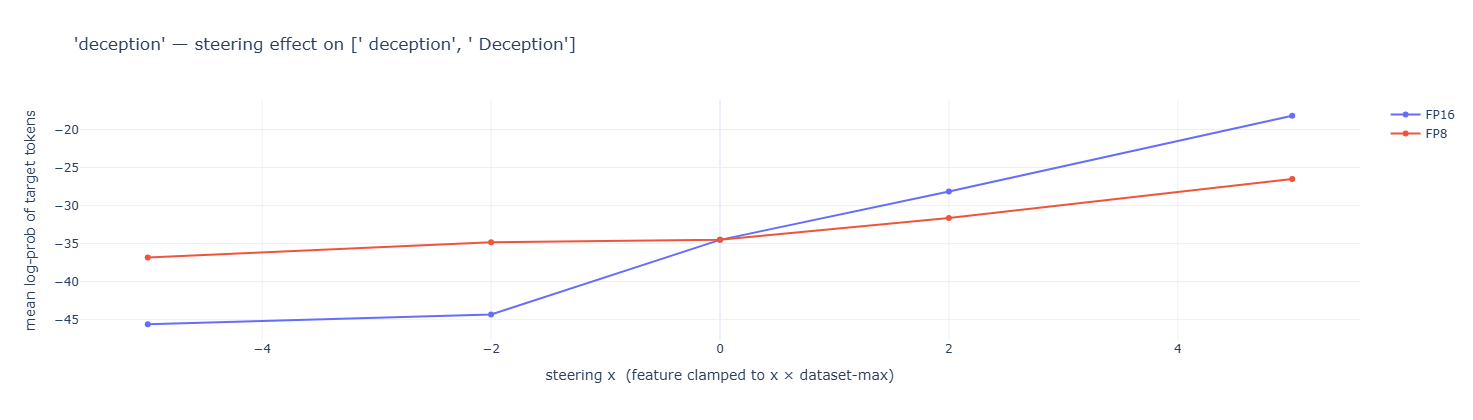

AssertionError: Input string:  trickery is not a single token!

In [11]:
import numpy as np
import plotly.graph_objects as go

signed_xs = sorted(STEER_X_SWEEP)
for c in CONCEPTS_TO_RUN:
    prompt = CONCEPT_PROMPTS.get(c, DEFAULT_STEER_PROMPT)
    fig = go.Figure()
    for name in saes:
        if name not in concepts[c]:
            continue
        info = concepts[c][name]
        ys = [float(S.target_logprob(model, saes[name]["sae"], info["feature"],
                                     prompt, CONCEPTS[c], x, info["max_act"]))
              for x in signed_xs]
        fig.add_trace(go.Scatter(x=signed_xs, y=ys, mode="lines+markers", name=name))
    fig.update_layout(
        title=f"'{c}' — steering effect on {CONCEPTS[c]}",
        xaxis_title="steering x  (feature clamped to x × dataset-max)",
        yaxis_title="mean log-prob of target tokens", width=720, height=420,
        template="plotly_white",
    )
    fig.show()

## Stage D2 — quantitative steering metric & the FP8↔FP16 clamp diagnosis

Stage D's curves read the concept's pull at a *single* next-token position. Here we score
steering the way we actually use it: **the feature is clamped to `STEER_METRIC_X × max_act`
and held throughout a full generation**, and we measure the concept over the *whole*
continuation. For each concept × SAE, `steering_lib.steering_metric` returns:

- **`target_lp_delta`** — Δ log prob-mass on the concept's target tokens, averaged over
  every generated position (steered − baseline). The headline "did steering inject the
  concept?" number.
- **`target_rate_delta`** — Δ fraction of generated tokens that *are* a target token (a hard
  behavioural readout).
- **`fluency_nll`** — NLL of the steered text under the *unsteered* model (flags steering
  that "wins" only by emitting degenerate text). `score` = `target_lp_delta` minus a soft
  penalty for being less fluent than baseline.
- **`inject_rel`** — the FP8 calibration number. The clamp sets the feature's latent to
  `target` and reconstructs (error-preserving), injecting `target · direction` into the
  residual; `inject_rel = ||target · direction|| / ||resid||` is the encoder-free, physical
  size of that push, directly comparable across SAEs.
- **`reencode_ratio`** — the SAE's readback of the clamped residual. It is *not* expected to
  equal 1 (encoder∘decoder ≠ identity), so treat it as a secondary hint about encoder
  geometry / feature splitting, **not** a correctness check on the clamp.

**Why FP8 can look weaker:** if FP8's `inject_rel` is well below FP16's at the same `x`, the
*same* `x` is a *physically weaker* push there (its `max_act` or decoder-row norm differ) — so
FP8 isn't worse at *learning* the feature, we're just hitting it with a smaller hammer; re-run
with FP8's `x` scaled so `inject_rel` matches. If instead `inject_rel` matches but
`target_lp_delta` is lower, FP8 likely **split** the concept across several latents (one of
which we picked), so a single clamp captures less of it — use `find_concept_features` +
`concept_direction` to steer along the *summed* direction of the top matches.

In [ ]:
import importlib
import numpy as np
import pandas as pd

S = importlib.reload(S)  # pick up steering_lib's new metric / clamp-fidelity helpers

# Score every concept in each SAE: clamp to STEER_METRIC_X × max_act, held THROUGHOUT
# generation, vs the unsteered baseline. Same seed => FP8 and FP16 see the same draw.
metric_rows = []
for c in CONCEPTS_TO_RUN:
    for name in saes:
        if name not in concepts[c]:
            continue
        info = concepts[c][name]
        m = S.steering_metric(
            model, saes[name]["sae"], info["feature"],
            CONCEPT_PROMPTS.get(c, DEFAULT_STEER_PROMPT), CONCEPTS[c], info["max_act"],
            x=STEER_METRIC_X, n_samples=N_METRIC_GEN,
            max_new_tokens=METRIC_MAX_NEW_TOKENS, seed=0,
        )
        m.update(concept=c, sae=name, feat=info["feature"], max_act=info["max_act"])
        metric_rows.append(m)

dfm = pd.DataFrame(metric_rows)
# `inject_rel` = ||target·direction|| / ||resid|| : the encoder-free, cross-SAE measure of
# how hard we are physically pushing (the calibration number). `reencode_ratio` is the SAE's
# readback of the clamped residual — NOT expected to equal 1 (encoder∘decoder ≠ identity);
# read it as a secondary hint about feature splitting / encoder geometry.
show_cols = ["concept", "sae", "feat", "max_act", "target_lp_delta", "target_rate_delta",
             "fluency_nll", "inject_rel", "reencode_ratio", "score"]
print(f"Per-concept steering metric  (clamp x={STEER_METRIC_X} × max_act, "
      f"{N_METRIC_GEN} gens, {METRIC_MAX_NEW_TOKENS} tokens):")
display(dfm[show_cols].round(3))

agg = (dfm.groupby("sae")[["target_lp_delta", "target_rate_delta", "fluency_nll",
                           "inject_rel", "reencode_ratio", "score"]]
       .mean().round(3))
print("\nMean over concepts (higher score = stronger steering that stays coherent):")
display(agg)

# Headline FP8-vs-FP16 comparison + the diagnosis (uses inject_rel = physical push size).
if {"FP8", "FP16"}.issubset(set(agg.index)):
    d_score = agg.loc["FP8", "score"] - agg.loc["FP16", "score"]
    d_push = agg.loc["FP8", "inject_rel"] - agg.loc["FP16", "inject_rel"]
    rel_gap = d_push / (agg.loc["FP16", "inject_rel"] + 1e-9)
    print(f"\nFP8 − FP16 mean score: {d_score:+.3f}   |   "
          f"FP8 − FP16 mean inject_rel: {d_push:+.3f} ({rel_gap:+.0%} of FP16's push)")
    if d_score < -0.05 and rel_gap < -0.10:
        print("→ FP8 steers weaker AND pushes physically less hard at the same x: a "
              "CALIBRATION gap (its max_act / decoder-row norm differ). Re-run after scaling "
              "FP8's x so inject_rel matches FP16's — if the score gap closes, FP8 learned "
              "the feature fine and was just under-driven.")
    elif d_score < -0.05:
        print("→ FP8 steers weaker even though the physical push matches FP16: likely FEATURE "
              "SPLITTING — the single keyword feature captures less of the concept. Use "
              "find_concept_features + concept_direction to steer the combined direction.")
    else:
        print("→ FP8 and FP16 steer comparably on this slate.")

In [ ]:
import plotly.graph_objects as go

# Side-by-side bars per concept: the steering score, and the clamp-fidelity diagnostic.
for col, title, ytitle in [
    ("score", "Steering score per concept (Δ target log-prob mass, fluency-penalised)",
     "score (higher = better)"),
    ("inject_rel", "Physical push size per concept (||target·direction|| ÷ ||resid||)",
     "inject_rel (calibration; compare FP8 vs FP16)"),
]:
    fig = go.Figure()
    for name in saes:
        sub = dfm[dfm.sae == name].set_index("concept").reindex(CONCEPTS_TO_RUN)
        fig.add_trace(go.Bar(x=CONCEPTS_TO_RUN, y=sub[col], name=name))
    fig.update_layout(barmode="group", title=title, template="plotly_white",
                      width=900, height=430, xaxis_title="concept", yaxis_title=ytitle)
    fig.show()

## Stage E — a *deceptive* feature discovered from TruthfulQA

Stages A–D located features by keyword. Here we instead **discover** a feature directly
from behavior: which single latent best tells **false** answers apart from **true** ones?

For every [TruthfulQA](https://huggingface.co/datasets/truthful_qa) question we build
truthful (`question + correct answer`) and deceptive (`question + incorrect answer`)
statements, encode the residual at the SAE hook, and aggregate each feature's activation
over the **answer** tokens. We then rank features by the standardized mean difference
(Cohen's *d*) between the deceptive and truthful classes — a univariate linear probe for
deception. The top feature fires *more* on false answers; we then **steer** with it
(clamp to `x × max_act`) exactly like any other concept feature, and check whether
amplifying it makes the model prefer false answers.

In [ ]:
# --- TruthfulQA "deceptive feature" config ---------------------------------
TQA_DATASET         = "truthful_qa"  # HF dataset id (generation split)
TQA_N_QUESTIONS     = 817            # questions to probe (None = all 817; smaller = faster)
TQA_CORRECT_PER_Q   = 2              # truthful answers per question
TQA_INCORRECT_PER_Q = 2              # deceptive answers per question
TQA_AGG             = "mean"         # aggregate feature acts over answer tokens: "mean"|"max"
TQA_MIN_FIRE_RATE   = 0.02           # ignore latents firing on < this fraction of answers
TQA_TOPK            = 15             # how many candidate features to show

# Factual prompts to demonstrate steering the deceptive feature (+x should push the
# continuation toward confident falsehoods, -x toward hedged / truthful text).
DECEPTION_PROMPTS = [
    "Q: What happens if you crack your knuckles a lot?\nA:",
    "Q: What is the capital of Australia?\nA:",
    "Q: Can you catch a cold from being cold?\nA:",
]
# (prompt, true answer, false answer) probes for the quantitative truth-gap curve.
TRUTH_GAP_PROBES = [
    ("Q: What is the capital of Australia?\nA:", "Canberra", "Sydney"),
    ("Q: How many senses do humans have?\nA:", "more than five", "exactly five"),
    ("Q: What happens if you swallow gum?\nA:",
     "it passes through your digestive system", "it stays in your stomach for seven years"),
]
print("TruthfulQA deceptive-feature config set "
      f"({TQA_N_QUESTIONS or 'all'} questions, agg={TQA_AGG}).")

In [ ]:
# Discover the deceptive feature INDEPENDENTLY in each SAE (FP8 / FP16 have unrelated
# indices), reusing one shared set of TruthfulQA statements for a fair comparison.
import importlib

import pandas as pd

S = importlib.reload(S)  # pick up steering_lib's TruthfulQA helpers without a kernel restart

tqa_statements = S.truthfulqa_statements(
    n_questions=TQA_N_QUESTIONS, correct_per_q=TQA_CORRECT_PER_Q,
    incorrect_per_q=TQA_INCORRECT_PER_Q, dataset_name=TQA_DATASET)

deceptive = {}  # SAE name -> {feature, max_act, candidates}
for name, d in saes.items():
    print(f"\n=== {name}: probing TruthfulQA for a deceptive feature ===")
    rows, info = S.find_deceptive_feature(
        model, d["sae"], statements=tqa_statements, agg=TQA_AGG,
        min_fire_rate=TQA_MIN_FIRE_RATE, top_k=TQA_TOPK)
    if not rows:
        print(f"  {name}: no feature passed the firing-rate floor — lower TQA_MIN_FIRE_RATE.")
        continue
    top = rows[0]
    # Steering scale: prefer the TruthfulQA answer-token max; fall back to the Pile scan.
    max_act = top["max_act"] or S.feature_max_act(d["dir"], top["feature"])
    deceptive[name] = {"feature": top["feature"], "max_act": float(max_act),
                       "candidates": rows}
    display(HTML(f"<b>{name}</b> — top deception-predictive latents "
                 f"(n={info['n_true']} true / {info['n_false']} false answers)"))
    display(pd.DataFrame(rows))
    print(f"  -> using feature {top['feature']} (deception d={top['deception_score']}, "
          f"max_act={max_act:.2f}) for steering")

### What does the deceptive feature fire on?

Its top max-activating contexts from the Pile scan (same Anthropic-style heatmap as Stage
B). A sanity check on *what* the latent represents — a genuinely deception-related feature
should look interpretable rather than like noise.

In [ ]:
for name, info in deceptive.items():
    feat = info["feature"]
    ex = S.top_activating_examples(model, saes[name]["sae"], [feat],
                                   n_examples=N_HEATMAP_EXAMPLES,
                                   n_tokens=EXAMPLES_SCAN_TOKENS)[feat]
    blocks = [f"<div style='font:13px monospace;margin:4px 0'><b>{name}</b> · "
              f"deceptive feature {feat}</div>"]
    for e in ex:
        blocks.append(S.token_heatmap_html(e["str_tokens"], e["acts"],
                                           max_act=info["max_act"]))
    if not ex:
        blocks.append("<div style='color:#a00'>no examples found — raise "
                      "EXAMPLES_SCAN_TOKENS</div>")
    display(HTML("<div style='max-width:900px'>" + "".join(blocks) + "</div>"))

### Steering with the deceptive feature

Clamp the deceptive feature to `x × max_act` for `x` in `STEER_X_SWEEP` and read the
continuations of a few factual prompts. If the feature is causal, `+x` (red) should make
the model assert falsehoods more confidently and `-x` (green) should make it hedge or
correct itself.

In [ ]:
import html as _html2

for prompt in DECEPTION_PROMPTS:
    display(HTML(f"<h4>prompt: <code>{_html2.escape(prompt)}</code></h4>"))
    rows_html = []
    for x in STEER_X_SWEEP:
        label = "baseline (x=0)" if x == 0 else f"x={x:+g}× max_act"
        bg = "#eef" if x == 0 else ("#fdeaea" if x > 0 else "#e9f7e9")
        cells = []
        for name, info in deceptive.items():
            outs = S.steer_generate(model, saes[name]["sae"], info["feature"],
                                    prompt, x, info["max_act"],
                                    n_samples=N_GEN, **GEN_KWARGS)
            blk = "".join(f"<div style='margin:3px 0;padding:4px;border-left:3px solid #ccc'>"
                          f"{_html2.escape(t.replace(chr(10), ' '))}</div>" for t in outs)
            cells.append("<td style='padding:6px;border:1px solid #eee;vertical-align:top;"
                         f"font:12px monospace;max-width:520px'>{blk}</td>")
        rows_html.append(f"<tr><td style='background:{bg};padding:6px;font-weight:bold'>"
                         f"{label}</td>" + "".join(cells) + "</tr>")
    header = "<th></th>" + "".join(
        f"<th style='padding:6px'>{n} · feat {deceptive[n]['feature']}</th>" for n in deceptive)
    display(HTML(f"<table style='border-collapse:collapse'><tr>{header}</tr>"
                 + "".join(rows_html) + "</table>"))

### Quantitative: does amplifying the feature make false answers more likely?

For a few `(prompt, true answer, false answer)` probes we measure the model's mean
per-token log-prob of each answer as we sweep the steering `x`, and plot the **truth gap**
`logp(false) − logp(true)`. A curve that rises with `x` is causal evidence that the latent
drives the model toward deception (gap > 0 ⇒ the false answer is preferred). If FP8 learned
the same causal feature as FP16, the two curves should track each other.

In [ ]:
import numpy as np
import plotly.graph_objects as go

signed_xs = sorted(STEER_X_SWEEP)
fig = go.Figure()
for name, info in deceptive.items():
    gaps = []
    for x in signed_xs:
        diffs = [
            S.answer_logprob(model, saes[name]["sae"], info["feature"], pre, false_a,
                             x, info["max_act"])
            - S.answer_logprob(model, saes[name]["sae"], info["feature"], pre, true_a,
                               x, info["max_act"])
            for pre, true_a, false_a in TRUTH_GAP_PROBES
        ]
        gaps.append(float(np.mean(diffs)))
    fig.add_trace(go.Scatter(x=signed_xs, y=gaps, mode="lines+markers",
                             name=f"{name} · feat {info['feature']}"))
fig.add_hline(y=0, line_dash="dot", line_color="#888")
fig.update_layout(
    title="Deceptive-feature steering — truth gap  logp(false) − logp(true)  vs x",
    xaxis_title="steering x  (deceptive feature clamped to x × max_act)",
    yaxis_title="mean (logp false − logp true)", width=760, height=440,
    template="plotly_white")
fig.show()

## Stage F — deception as a *set* of latents (multi-feature probe + direction steering)

A single latent (Stage E) was a weak, possibly-confounded steering vector. Deception is
more plausibly **distributed** across many latents, so here we:

1. Fit a **sparse logistic-regression probe** over the SAE features (mean-pooled over
   answer tokens) to predict false-vs-true on TruthfulQA, using a **question-grouped
   train/test split** (a question's true & false variants never straddle the split, so
   the held-out AUC measures generalization to *new* questions, not memorized topics).
   Target: held-out AUC/accuracy **> 0.9**.
2. Build a **residual-space deception direction** = the probe's weighted sum of the
   selected features' decoder directions, and steer by *adding* it to the residual
   stream. Because it's a unit direction scaled in residual-norm units, it sidesteps the
   weak-magnitude problem that made single-feature clamping do nothing.

If the probe clears 0.9 and the direction steers (generations + truth-gap curve move),
that's the multi-latent deception representation you were after — and FP8 vs FP16 should
again track each other.

In [ ]:
# --- Multi-feature deception probe config ----------------------------------
PROBE_N_QUESTIONS    = 817      # TruthfulQA questions for the probe (more = better probe)
PROBE_CORRECT_PER_Q  = 2
PROBE_INCORRECT_PER_Q = 3       # TruthfulQA has more incorrect answers; use a few
PROBE_AGG            = "mean"   # answer-token aggregation: "mean" | "max"
PROBE_MIN_FIRED      = 3        # only consider latents firing in >= this many statements
PROBE_PENALTY        = "l1"     # "l1" => sparse SET of latents; "l2" => dense
PROBE_C              = 0.5      # inverse reg strength; raise toward 1-5 if AUC < 0.9
PROBE_TEST_FRAC      = 0.3
PROBE_MAX_SELECT     = 64       # how many top-|weight| latents define the steering direction

# Direction steering is in residual-norm units: coeff = multiplier × (mean resid norm at
# the hook). +mult pushes toward DECEPTIVE, -mult toward truthful.
DIR_COEFF_MULTS = [-0.6, -0.3, 0.0, 0.3, 0.6]
print("Stage F probe config set "
      f"({PROBE_N_QUESTIONS} questions, penalty={PROBE_PENALTY}, C={PROBE_C}).")

In [ ]:
# Fit a deception probe per SAE and build its steering direction. Shared TruthfulQA
# statements -> fair FP8-vs-FP16 comparison.
import importlib

import pandas as pd

S = importlib.reload(S)

probe_statements = S.truthfulqa_statements(
    n_questions=PROBE_N_QUESTIONS, correct_per_q=PROBE_CORRECT_PER_Q,
    incorrect_per_q=PROBE_INCORRECT_PER_Q, dataset_name=TQA_DATASET)

probes = {}  # SAE name -> {probe, direction, resid_norm}
for name, d in saes.items():
    print(f"\n=== {name}: fitting multi-feature deception probe ===")
    X, y, groups, feats, mat_info = S.truthfulqa_feature_matrix(
        model, d["sae"], probe_statements, agg=PROBE_AGG,
        min_statements_fired=PROBE_MIN_FIRED)
    probe = S.fit_deception_probe(
        X, y, groups=groups, feats=feats, penalty=PROBE_PENALTY, C=PROBE_C,
        test_frac=PROBE_TEST_FRAC, max_select=PROBE_MAX_SELECT)
    direction = S.probe_direction(d["sae"], probe["selected"], normalize=True)
    rnorm = S.resid_norm_at_hook(model, d["sae"])
    probes[name] = {"probe": probe, "direction": direction, "resid_norm": rnorm}

    info = probe["info"]
    ok = "PASS" if (info["test_auc"] or 0) >= 0.9 else "below 0.9 — raise PROBE_C / lower PROBE_MIN_FIRED"
    display(HTML(f"<b>{name}</b> — deception probe: test AUC "
                 f"<b>{info['test_auc']}</b>, test acc {info['test_acc']} "
                 f"({info['n_nonzero']} nonzero latents; {ok})"))
    display(pd.DataFrame(probe["selected"][:15]))
    print(f"  resid norm at hook ~{rnorm:.1f}; steering coeffs = "
          f"{[round(m*rnorm,1) for m in DIR_COEFF_MULTS]}")

### Steering along the multi-latent deception direction

Add `coeff × direction` to the residual at the SAE hook, sweeping `coeff` as multiples of
the measured residual norm. `+coeff` (red) should push toward confident falsehoods,
`-coeff` (green) toward hedged / corrected text.

In [ ]:
import html as _html3

for prompt in DECEPTION_PROMPTS:
    display(HTML(f"<h4>prompt: <code>{_html3.escape(prompt)}</code></h4>"))
    rows_html = []
    for mult in DIR_COEFF_MULTS:
        label = "baseline (0)" if mult == 0 else f"{mult:+g}× resid-norm"
        bg = "#eef" if mult == 0 else ("#fdeaea" if mult > 0 else "#e9f7e9")
        cells = []
        for name, p in probes.items():
            coeff = mult * p["resid_norm"]
            outs = S.steer_generate_dir(model, saes[name]["sae"], p["direction"],
                                        prompt, coeff, n_samples=N_GEN, **GEN_KWARGS)
            blk = "".join(f"<div style='margin:3px 0;padding:4px;border-left:3px solid #ccc'>"
                          f"{_html3.escape(t.replace(chr(10), ' '))}</div>" for t in outs)
            cells.append("<td style='padding:6px;border:1px solid #eee;vertical-align:top;"
                         f"font:12px monospace;max-width:520px'>{blk}</td>")
        rows_html.append(f"<tr><td style='background:{bg};padding:6px;font-weight:bold'>"
                         f"{label}</td>" + "".join(cells) + "</tr>")
    header = "<th></th>" + "".join(
        f"<th style='padding:6px'>{n} · {len(probes[n]['probe']['selected'])} latents</th>"
        for n in probes)
    display(HTML(f"<table style='border-collapse:collapse'><tr>{header}</tr>"
                 + "".join(rows_html) + "</table>"))

### Quantitative: truth gap vs steering along the deception direction

Same truth-gap metric as Stage E (`logp(false) − logp(true)`), but sweeping the
multi-latent direction's coefficient. A monotonic rise is causal evidence that the
*set* of latents encodes deception; FP8 and FP16 curves tracking each other extends the
equivalence claim to this distributed representation.

In [ ]:
import numpy as np
import plotly.graph_objects as go

fig = go.Figure()
for name, p in probes.items():
    rnorm = p["resid_norm"]
    coeffs = [m * rnorm for m in DIR_COEFF_MULTS]
    gaps = []
    for coeff in coeffs:
        diffs = [
            S.answer_logprob_dir(model, saes[name]["sae"], p["direction"], pre, false_a, coeff)
            - S.answer_logprob_dir(model, saes[name]["sae"], p["direction"], pre, true_a, coeff)
            for pre, true_a, false_a in TRUTH_GAP_PROBES
        ]
        gaps.append(float(np.mean(diffs)))
    fig.add_trace(go.Scatter(x=DIR_COEFF_MULTS, y=gaps, mode="lines+markers",
                             name=f"{name} (AUC {p['probe']['info']['test_auc']})"))
fig.add_hline(y=0, line_dash="dot", line_color="#888")
fig.update_layout(
    title="Multi-latent deception direction — truth gap  logp(false) − logp(true)  vs steering",
    xaxis_title="steering coeff  (× residual norm; + = toward deceptive)",
    yaxis_title="mean (logp false − logp true)", width=780, height=440,
    template="plotly_white")
fig.show()

## Takeaways

- **Heatmaps (Stage B)** show the feature fires specifically on the concept tokens →
  the SAE learned a meaningful, monosemantic feature, not noise.
- **Steering (Stage C)** shows clamping that single feature *causally* steers generation
  toward (`+x`) / away from (`-x`) the concept → the feature is behaviorally real.
- **Curves (Stage D)** show the FP8 and FP16 features produce the **same steering response**
  → FP8 training preserves the causal feature geometry; it's not just close on
  reconstruction metrics, it's interpretably and causally equivalent.
- **Deceptive feature (Stage E)** is *discovered from behavior* (TruthfulQA), not a keyword:
  the single latent that best separates false from true answers. A lone latent is often a
  weak / confounded steering vector, which motivates Stage F.
- **Deception direction (Stage F)** treats deception as a *set* of latents: a sparse
  logistic probe (question-grouped train/test, target AUC > 0.9) defines a residual-space
  direction from many features' decoders. Steering along it (scaled in residual-norm units)
  is both more predictive and a stronger intervention than clamping one latent — and FP8 vs
  FP16 tracking each other extends the equivalence claim to a distributed representation.

To change which concepts run, edit `CONCEPTS` / `CONCEPTS_TO_RUN` in the config. The
deceptive-feature search is tuned via the `TQA_*` knobs (Stage E config). To swap
models/SAEs, edit `SAES` — everything else (base model, hook, layer) is read from each SAE's
own config.

In [10]:

from openai import OpenAI
import httpx

http_client = httpx.Client(verify=False)

client = OpenAI(
    api_key="ak-<your-safe-apikey>",
    base_url="https://core42.primus-safe.amd.com/api/v1/llm-proxy/v1",
    http_client=http_client,
)

models = client.models.list()
for model in models.data:
    print(model.id)

response = client.chat.completions.create(
    model="openai/gpt-5.2",
    messages=[{"role": "user", "content": "Hello!"}],
)
print(response.choices[0].message.content)


gpt-5.2
gpt-5.4-mini
gpt-5.3-codex
gpt-5.4
claude-opus-4-6
all-proxy-models
gemini/gemini-3.1-pro-preview
gpt-5.5
claude-opus-4-5
claude-haiku-4-5-20251001
text-embedding-3-large
claude-opus-4-8
claude-opus-4-7
gpt-4.1
dvue-aoai-005-Kimi-K2.6
Hello! What can I help you with today?
